Importing Libraries

In [2]:
# for numberical operations
import numpy as np

# for dataframe operations
import pandas as pd

# data visualizations
import matplotlib.pyplot as plt
import seaborn as sns

# for machine learning algorithms
import sklearn
import imblearn

Reading the Dataset

In [3]:
# lets import the dataset using the read_csv function
data = pd.read_csv(r"C:\Users\Aryan\OneDrive\Desktop\LoanData.csv")

# lets check the shape of the dataset
data.shape

(614, 13)

In [4]:
# lets check the column names present in the dataset
data.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [5]:
# lets check the head of the dataset
data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


Descriptive Statistics

In [6]:
# for numberical variables
data.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [7]:
# for categorical variables
data.describe(include = 'object')

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status
count,614,601,611,599,614,582,614,614
unique,614,2,2,4,2,2,3,2
top,LP002990,Male,Yes,0,Graduate,No,Semiurban,Y
freq,1,489,398,345,480,500,233,422


In [8]:
data['Loan_Status'].value_counts()

Loan_Status
Y    422
N    192
Name: count, dtype: int64

Data Cleaning

In [9]:
# checking no. of Missing values
data.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [10]:
# using mode values to imput categorical columns

data['Gender']=data['Gender'].fillna(data['Gender'].mode()[0])
data['Married']=data['Married'].fillna(data['Married'].mode()[0])
data['Dependents']=data['Dependents'].fillna(data['Dependents'].mode()[0])
data['Self_Employed']=data['Self_Employed'].fillna(data['Self_Employed'].mode()[0])

#Using median values to impute the numberical columns

data['LoanAmount']=data['LoanAmount'].fillna(data['LoanAmount'].median())
data['Loan_Amount_Term']=data['Loan_Amount_Term'].fillna(data['Loan_Amount_Term'].median())
data['Credit_History']=data['Credit_History'].fillna(data['Credit_History'].median())

#lets check if there is any null values left or not
data.isnull().sum().sum()

np.int64(0)

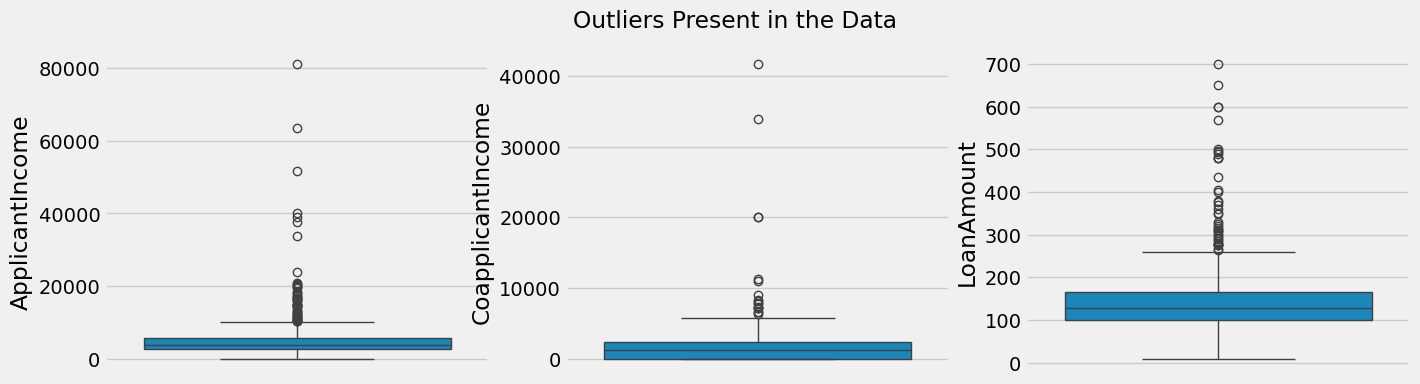

In [11]:
# lets visualize the outliers using Box plot

plt.style.use('fivethirtyeight')
plt.rcParams['figure.figsize']=(15,4)

plt.subplot(1, 3, 1)
sns.boxplot(data['ApplicantIncome'])

plt.subplot(1, 3, 2)
sns.boxplot(data['CoapplicantIncome'])

plt.subplot(1, 3, 3)
sns.boxplot(data['LoanAmount'])

plt.suptitle('Outliers Present in the Data')
plt.show()

In [12]:
# lets remove the otliers from the data

# lets check the shape before removing outliers
print("Before Removing Outliers", data.shape)

# lets filter the customers having more than 25000 income
data = data[data['ApplicantIncome'] < 25000]

# lets check the shape after removing outliers
print("After Removing outliers", data.shape)

Before Removing Outliers (614, 13)
After Removing outliers (607, 13)


In [13]:
# lets remarks the outliers from co-applicant's Income

# lets check the shape before removing outliers
print("Before Removing Outliers",data.shape)
# lets filter the customers having more than 10000 coapplicant income
data = data[data['CoapplicantIncome'] < 10000]

# lets check the shape after remocing outliers
print("After Removing Outliers", data.shape)

Before Removing Outliers (607, 13)
After Removing Outliers (601, 13)


In [14]:
# lets remove the outliers from Loan Amount

# lets check the shape before removing outliers
print("Before Remvoing Outliers", data.shape)

# lets filter the customers having more than 400 loan amount
data = data[data['LoanAmount']< 400]

# lets check the shape after removing outliers
print("After Removing Outliers", data.shape)

Before Remvoing Outliers (601, 13)
After Removing Outliers (590, 13)


Univariate Data Analysis

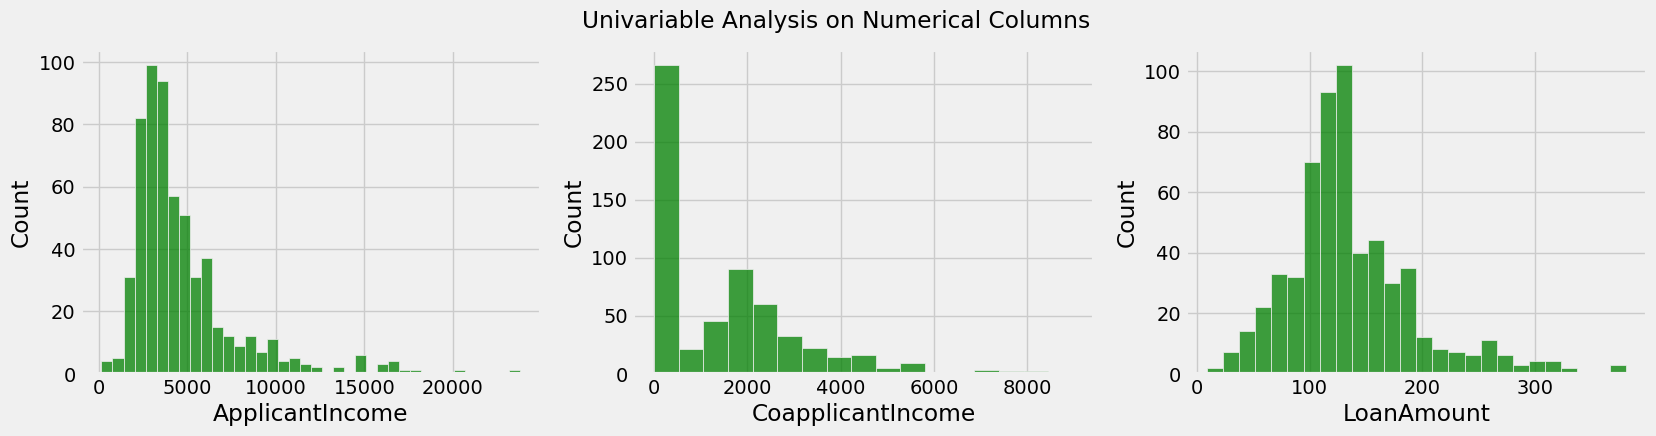

In [15]:
# Univeriate Analysis on Numberical Columns

plt.rcParams['figure.figsize'] = (18, 4)
plt.subplot(1, 3, 1)
sns.histplot(data['ApplicantIncome'], color = 'green')

plt.subplot(1, 3, 2)
sns.histplot(data['CoapplicantIncome'], color = 'green')

plt.subplot(1, 3, 3)
sns.histplot(data['LoanAmount'], color = 'green')

plt.suptitle('Univariable Analysis on Numerical Columns')
plt.show()

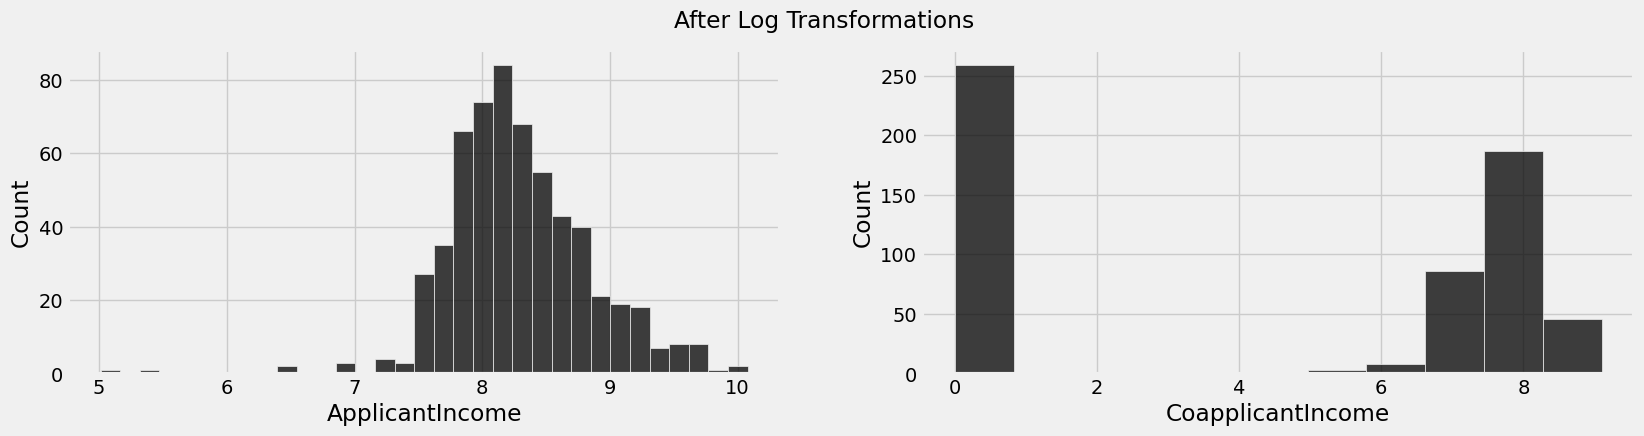

In [16]:
# lets remove skewness from ApplicantIncome and Coapplicant Incomme, as it can add bias to the data

import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (18, 4)

# lets apply log transformation to remove skewness
data['ApplicantIncome'] = np.log(data['ApplicantIncome'])
data['CoapplicantIncome'] = np.log1p(data['CoapplicantIncome'])

# lets plot them and check whether skewness is removed or not
plt.subplot(1, 2, 1)
sns.histplot(data['ApplicantIncome'], color = 'black')

plt.subplot(1, 2, 2)
sns.histplot(data['CoapplicantIncome'], color = 'black')

plt.suptitle('After Log Transformations')
plt.show()

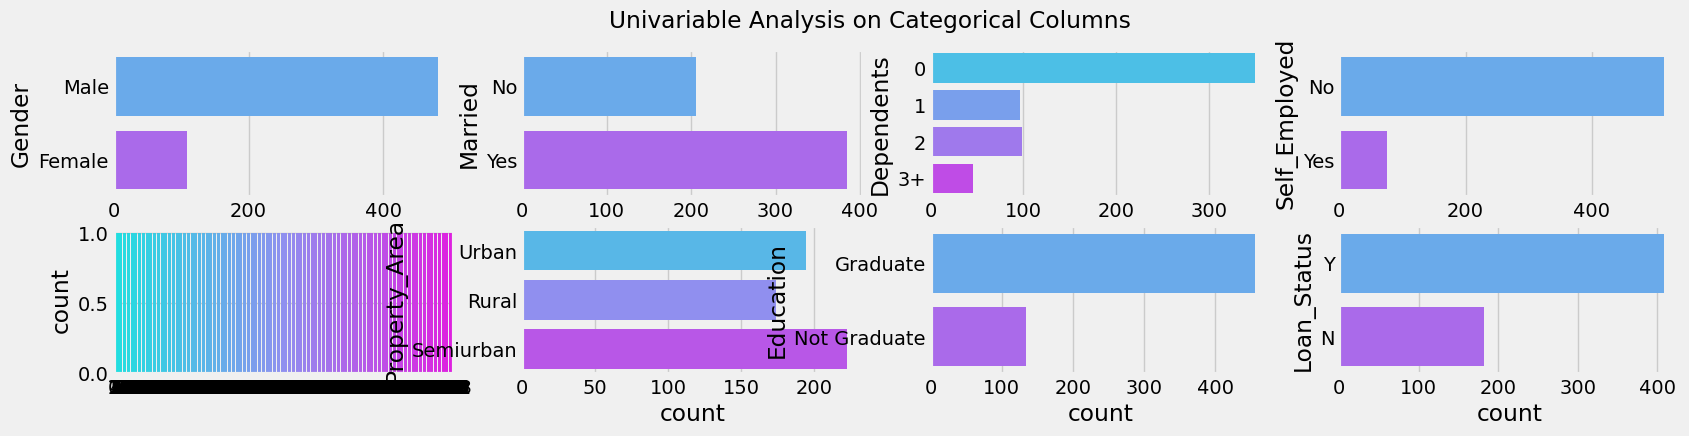

In [17]:
# Univariate Analysis on Categorical Columns

plt.subplot(2, 4, 1)
sns.countplot(data['Gender'], palette = 'cool')

plt.subplot(2, 4, 2)
sns.countplot(data['Married'], palette = 'cool')

plt.subplot(2, 4, 3)
sns.countplot(data['Dependents'], palette = 'cool')

plt.subplot(2, 4, 4)
sns.countplot(data['Self_Employed'], palette = 'cool')

plt.subplot(2, 4, 5)
sns.countplot(data['Credit_History'], palette = 'cool')

plt.subplot(2, 4, 6)
sns.countplot(data['Property_Area'], palette = 'cool')

plt.subplot(2, 4, 7)
sns.countplot(data['Education'], palette = 'cool')

plt.subplot(2, 4, 8)
sns.countplot(data['Loan_Status'], palette = 'cool')

plt.suptitle('Univariable Analysis on Categorical Columns')
plt.show()

 Bivariate Data Analysis

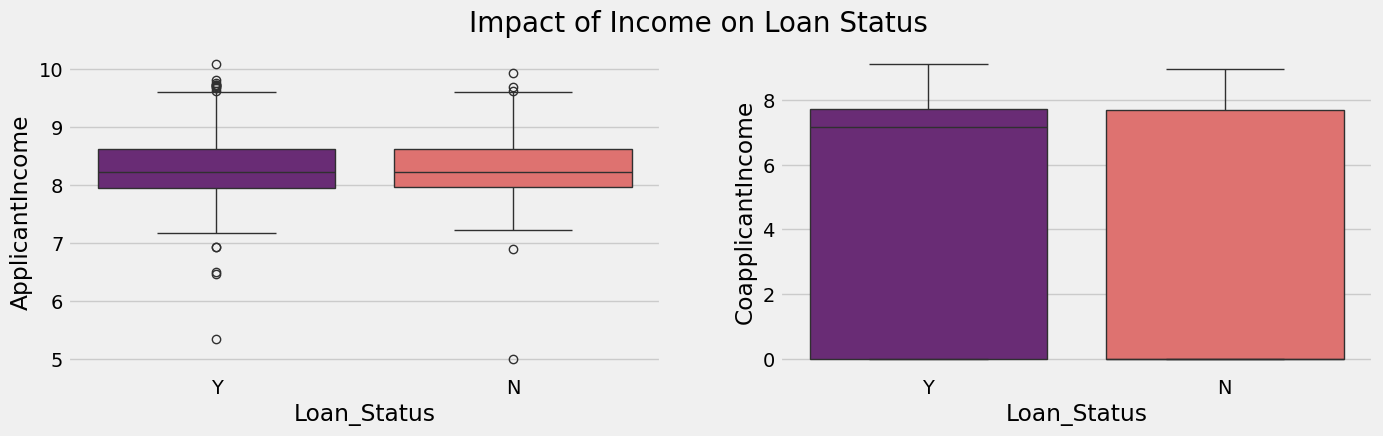

In [18]:
# lets check the Impact of Income of Applicant and Co-applicant on Loan Status

plt.rcParams['figure.figsize'] = (15, 4)

plt.subplot(1, 2, 1)
sns.boxplot(x=data['Loan_Status'], y=data['ApplicantIncome'], palette = 'magma')

plt.subplot(1, 2, 2)
sns.boxplot(x=data['Loan_Status'], y=data['CoapplicantIncome'], palette = 'magma')

plt.suptitle('Impact of Income on Loan Status\n', fontsize = 20)
plt.show()

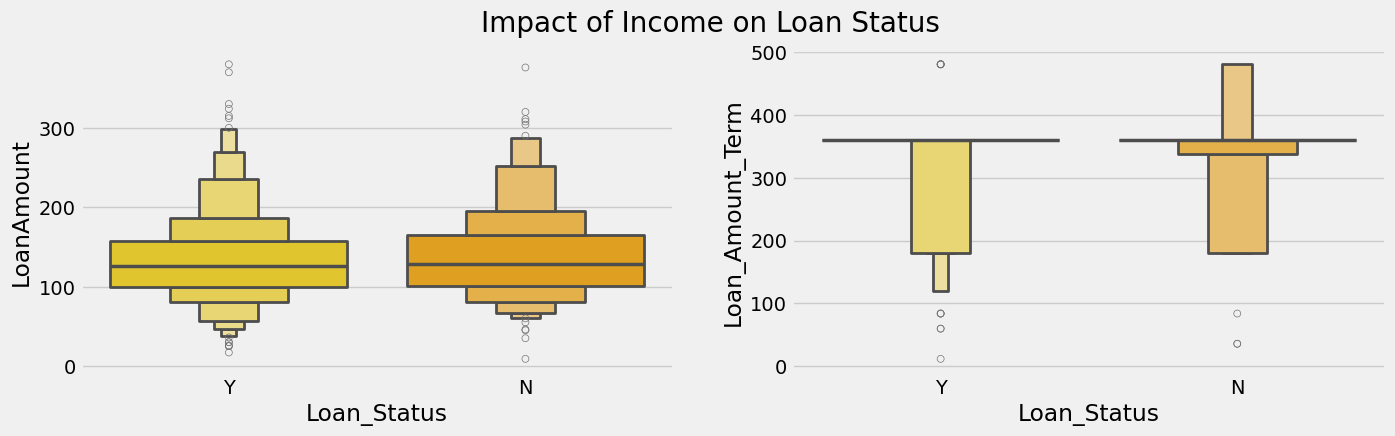

In [19]:
# lets check the Impact of Amount on Loan Status

plt.rcParams['figure.figsize'] = (15,4)

plt.subplot(1, 2, 1)
sns.boxenplot(x=data['Loan_Status'], y=data['LoanAmount'], palette = 'Wistia')

plt.subplot(1, 2, 2)
sns.boxenplot(x=data['Loan_Status'], y=data['Loan_Amount_Term'], palette = 'Wistia')

plt.suptitle('Impact of Income on Loan Status\n', fontsize = 20)
plt.show()

 Comparing Categorical Data with target Columns

In [20]:
# lets compare all the Categories woth respect to the Status to understand the overall Impact

print("Impact of Marriage on Loan Status")
print(pd.crosstab(data['Loan_Status'], data['Married']))
print('\n')

print("Impact of Dependents on Loan Status")
print(pd.crosstab(data['Loan_Status'], data['Dependents']))
print('\n')

print("Impact of Education on Loan Status")
print(pd.crosstab(data['Loan_Status'], data['Education']))
print('\n')

print("Impact of Education on Loan Status")
print(pd.crosstab(data['Loan_Status'], data['Self_Employed']))
print('\n')

print("Impact of Property on Loan Status")
print(pd.crosstab(data['Loan_Status'], data['Property_Area']))


Impact of Marriage on Loan Status
Married       No  Yes
Loan_Status          
N             76  106
Y            130  278


Impact of Dependents on Loan Status
Dependents     0   1   2  3+
Loan_Status                 
N            110  33  24  15
Y            240  63  74  31


Impact of Education on Loan Status
Education    Graduate  Not Graduate
Loan_Status                        
N                 130            52
Y                 326            82


Impact of Education on Loan Status
Self_Employed   No  Yes
Loan_Status            
N              157   25
Y              357   51


Impact of Property on Loan Status
Property_Area  Rural  Semiurban  Urban
Loan_Status                           
N                 66         51     65
Y                108        171    129


Data Preparation

In [21]:
# lets check the columns which are of object data types
data.select_dtypes('object').head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,Urban,Y
4,LP001008,Male,No,0,Graduate,No,Urban,Y


In [22]:
# lets delete the loan Id column from the data as this columns has no relation with loan status

# lets check the shap of the data before deleting the columns
print("Before Deletingg Columns :", data.shape)

data = data.drop(['Loan_ID'], axis = 1)

#lets check the shape of the data after deleting the columns
print("After Deleting Columns :", data.shape)

Before Deletingg Columns : (590, 13)
After Deleting Columns : (590, 12)


In [23]:
# lets ecode other collummns
data['Gender'] = data['Gender'].replace(('Male','Female'),(1,0))
data['Married'] = data['Married'].replace(('Yes','No'),(1,0))
data['Education'] = data['Education'].replace(('Gradute', 'Not Graduate'),(1,0))
data['Self_Employed'] = data['Self_Employed'].replace(('Yes','No'),(1, 0))
data['Loan_Status'] = data['Loan_Status'].replace(('Y','N'),(1, 0))

# as seen above that urban and Semi Urban and Semi Urban Property have very Similar Impact on Loan Status, so, we will merge the, together 
data['Property_Aread'] = data['Property_Area'].replace(('urban','Semiurban','Rural'),(1, 1, 0))

# as seen above that apart from 0 dependents, all are Similar hence, we merge them to avoid any confusion
data['Dependents'] = data['Dependents'].replace(('0', '1', '2', '3+'), (0, 1, 1, 1))

# lets check whether there is any object column left
data.select_dtypes('object').columns

Index(['Education', 'Property_Area', 'Property_Aread'], dtype='object')

In [24]:
# lets split the target volumns from the data

y=data['Loan_Status']
x=data.drop(['Loan_Status'], axis=1)

#lets check the shape of x and y
print("Shape of x:", x.shape)
print("Shape of y:", y.shape)

Shape of x: (590, 12)
Shape of y: (590,)


Resamplinng for Balancing the Data

In [28]:
x_encoded = pd.get_dummies(x, drop_first=True)

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

x_resample, y_resample = smote.fit_resample(
    x_encoded,
    y.values.ravel()
)

print(x_resample.shape)
print(y_resample.shape)

(816, 14)
(816,)


In [29]:
# lets also check the valuee counts of our target variable4

print("Before Resampling:")
print(y.value_counts())

print("After Resampling:")
y_resample = pd.DataFrame(y_resample)
print(y_resample[0].value_counts())

Before Resampling:
Loan_Status
1    408
0    182
Name: count, dtype: int64
After Resampling:
0
1    408
0    408
Name: count, dtype: int64


In [30]:
# lets split the test data from the training data

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x_resample, y_resample, test_size = 0.2, random_state = 0)

# lets print the shaped again
print("Shape of the x Train:", x_train.shape)
print("Shape of the y Train:", y_train.shape)
print("Shape of the x Test:", x_test.shape)
print("Shape of the y Test:", y_test.shape)

Shape of the x Train: (652, 14)
Shape of the y Train: (652, 1)
Shape of the x Test: (164, 14)
Shape of the y Test: (164, 1)


Machine Learning Modelling

In [31]:
# lets apply Logistic Regression

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state = 0)
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

print("Training Accuracy:", model.score(x_train, y_train))
print("Testing Accuracy:",model.score(x_test, y_test))


Training Accuracy: 0.7791411042944786
Testing Accuracy: 0.8048780487804879


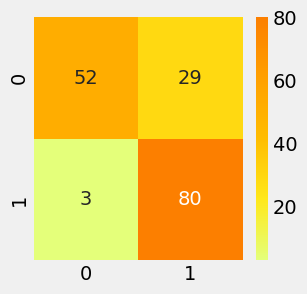

              precision    recall  f1-score   support

           0       0.95      0.64      0.76        81
           1       0.73      0.96      0.83        83

    accuracy                           0.80       164
   macro avg       0.84      0.80      0.80       164
weighted avg       0.84      0.80      0.80       164



In [34]:
# lets analyze the Performance using Confusion matrix

from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, y_pred)
plt.rcParams['figure.figsize']=(3,3)
sns.heatmap(cm, annot = True, cmap = 'Wistia', fmt = '.8g')
plt.show()

# lets sldo use classification report for performance analysis
cr = classification_report(y_test, y_pred)
print(cr)


Applying Gradient Boosting


In [36]:
# lets apply DecisionTrees
from sklearn.ensemble import GradientBoostingClassifier

model = GradientBoostingClassifier()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

print("Testing Accuracy:", model.score(x_train, y_train))
print("Testing Accuracy:", model.score(x_test, y_test))

Testing Accuracy: 0.9049079754601227
Testing Accuracy: 0.7987804878048781


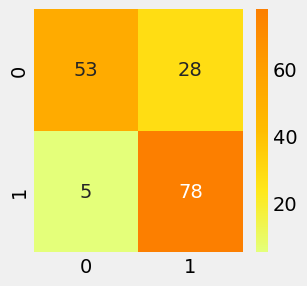

              precision    recall  f1-score   support

           0       0.91      0.65      0.76        81
           1       0.74      0.94      0.83        83

    accuracy                           0.80       164
   macro avg       0.82      0.80      0.79       164
weighted avg       0.82      0.80      0.79       164



In [37]:
# lets analyze the Performance using Confusion matrix

cm=confusion_matrix(y_test, y_pred)
plt.rcParams['figure.figsize'] = (3, 3)
sns.heatmap(cm, annot =True, cmap = 'Wistia', fmt = '.8g')
plt.show()

# lets also use classification report for performance analysis
cr = classification_report(y_test, y_pred)
print(cr)


In [39]:
from sklearn.model_selection import cross_val_score

clf = GradientBoostingClassifier(random_state = 0)
scores = cross_val_score(clf,  x_train, y_train, cv=10)
print(scores)

[0.71212121 0.8030303  0.83076923 0.81538462 0.75384615 0.78461538
 0.78461538 0.73846154 0.75384615 0.81538462]
